In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

In [ ]:
# Load data
data = np.load('/home/kulraj/nepali_ocr/data/dataset.npz')

X_train = data['arr_0']   # (78200, 32, 32)
y_train = data['arr_1']   # (78200,)  labels 1-46
X_test  = data['arr_2']   # (13800, 32, 32)
y_test  = data['arr_3']   # (13800,)  labels 1-46

# Labels must start from 0 not 1
y_train = y_train - 1
y_test  = y_test  - 1

print("Train:", X_train.shape, "| Labels range:", y_train.min(), "to", y_train.max())
print("Test: ", X_test.shape,  "| Labels range:", y_test.min(),  "to", y_test.max())

In [ ]:
# Dataset class
class DHCDDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images.astype(np.float32) / 255.0
        self.labels = labels.astype(np.int64)
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx]).unsqueeze(0)  # (1, 32, 32)
        if self.augment:
            img = T.RandomRotation(10)(img)
            img = T.RandomAffine(degrees=0, translate=(0.1, 0.1))(img)
        img = T.Normalize((0.5,), (0.5,))(img)
        return img, self.labels[idx]

train_ds = DHCDDataset(X_train, y_train, augment=True)
test_ds  = DHCDDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)
# Quick check
imgs, labels = next(iter(train_loader))
print("Batch image shape:", imgs.shape)    # should be torch.Size([64, 1, 32, 32])
print("Batch label shape:", labels.shape)  # should be torch.Size([64])

In [ ]:
# CNN Model
class NepaliOCR_CNN(nn.Module):
    def __init__(self, num_classes=46):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = NepaliOCR_CNN(num_classes=46).to(device)

# Test with dummy input
dummy = torch.zeros(8, 1, 32, 32).to(device)
out   = model(dummy)
print("Output shape:", out.shape)   # should be torch.Size([8, 46])
print("Model ready!")

In [ ]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

EPOCHS = 30

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    total_loss = 0
    correct    = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()

    train_acc = correct / len(train_ds) * 100

    # --- Evaluate ---
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            val_correct += (model(imgs).argmax(1) == labels).sum().item()

    val_acc = val_correct / len(test_ds) * 100
    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

print("\nTraining complete!")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

prop = fm.FontProperties(fname='/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf')

CLASS_NAMES = ['क','ख','ग','घ','ङ','च','छ','ज','झ','ञ',
               'ट','ठ','ड','ढ','ण','त','थ','द','ध','न',
               'प','फ','ब','भ','म','य','र','ल','व','श',
               'ष','स','ह','क्ष','त्र','ज्ञ',
               '०','१','२','३','४','५','६','७','८','९']

model.eval()
fig, axes = plt.subplots(3, 6, figsize=(16, 8))

for ax in axes.flat:
    idx = np.random.randint(0, len(X_test))
    img_np     = X_test[idx]
    true_label = y_test[idx]

    img_tensor = torch.tensor(img_np.astype(np.float32) / 255.0)
    img_tensor = (img_tensor.unsqueeze(0).unsqueeze(0) - 0.5) / 0.5
    with torch.no_grad():
        out  = model(img_tensor)
        pred = out.argmax(1).item()
        conf = out.softmax(1)[0][pred].item()

    color = 'green' if pred == true_label else 'red'
    ax.imshow(img_np, cmap='gray')
    ax.set_title(f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred]} ({conf*100:.1f}%)",
                 fontproperties=prop, fontsize=10, color=color)
    ax.axis('off')

plt.suptitle('Green = Correct   Red = Wrong', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(16, 8))

for ax in axes.flat:
    idx = np.random.randint(0, len(X_test))
    img_np     = X_test[idx]
    true_label = y_test[idx]

    img_tensor = torch.tensor(img_np.astype(np.float32) / 255.0)
    img_tensor = (img_tensor.unsqueeze(0).unsqueeze(0) - 0.5) / 0.5
    with torch.no_grad():
        out  = model(img_tensor)
        pred = out.argmax(1).item()
        conf = out.softmax(1)[0][pred].item()

    color = 'green' if pred == true_label else 'red'
    ax.imshow(img_np, cmap='gray')

    # English text with default font
    ax.set_xlabel(f"{'Correct' if pred==true_label else 'WRONG'} {conf*100:.1f}%",
                  color=color, fontsize=9)

    # Nepali characters with Devanagari font
    ax.set_title(f"{CLASS_NAMES[true_label]} → {CLASS_NAMES[pred]}",
                 fontproperties=prop, fontsize=14, color=color)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle('Nepali OCR Results  |  Green = Correct   Red = Wrong', fontsize=13)
plt.tight_layout()
plt.show()

Model loaded!
Total predictions: 13800


/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.draw()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2326 (\N{DEVANAGARI LETTER KHA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2327 (\N{DEVANAGARI LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2328 (\N{DEVANAGARI LETTER GHA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning:

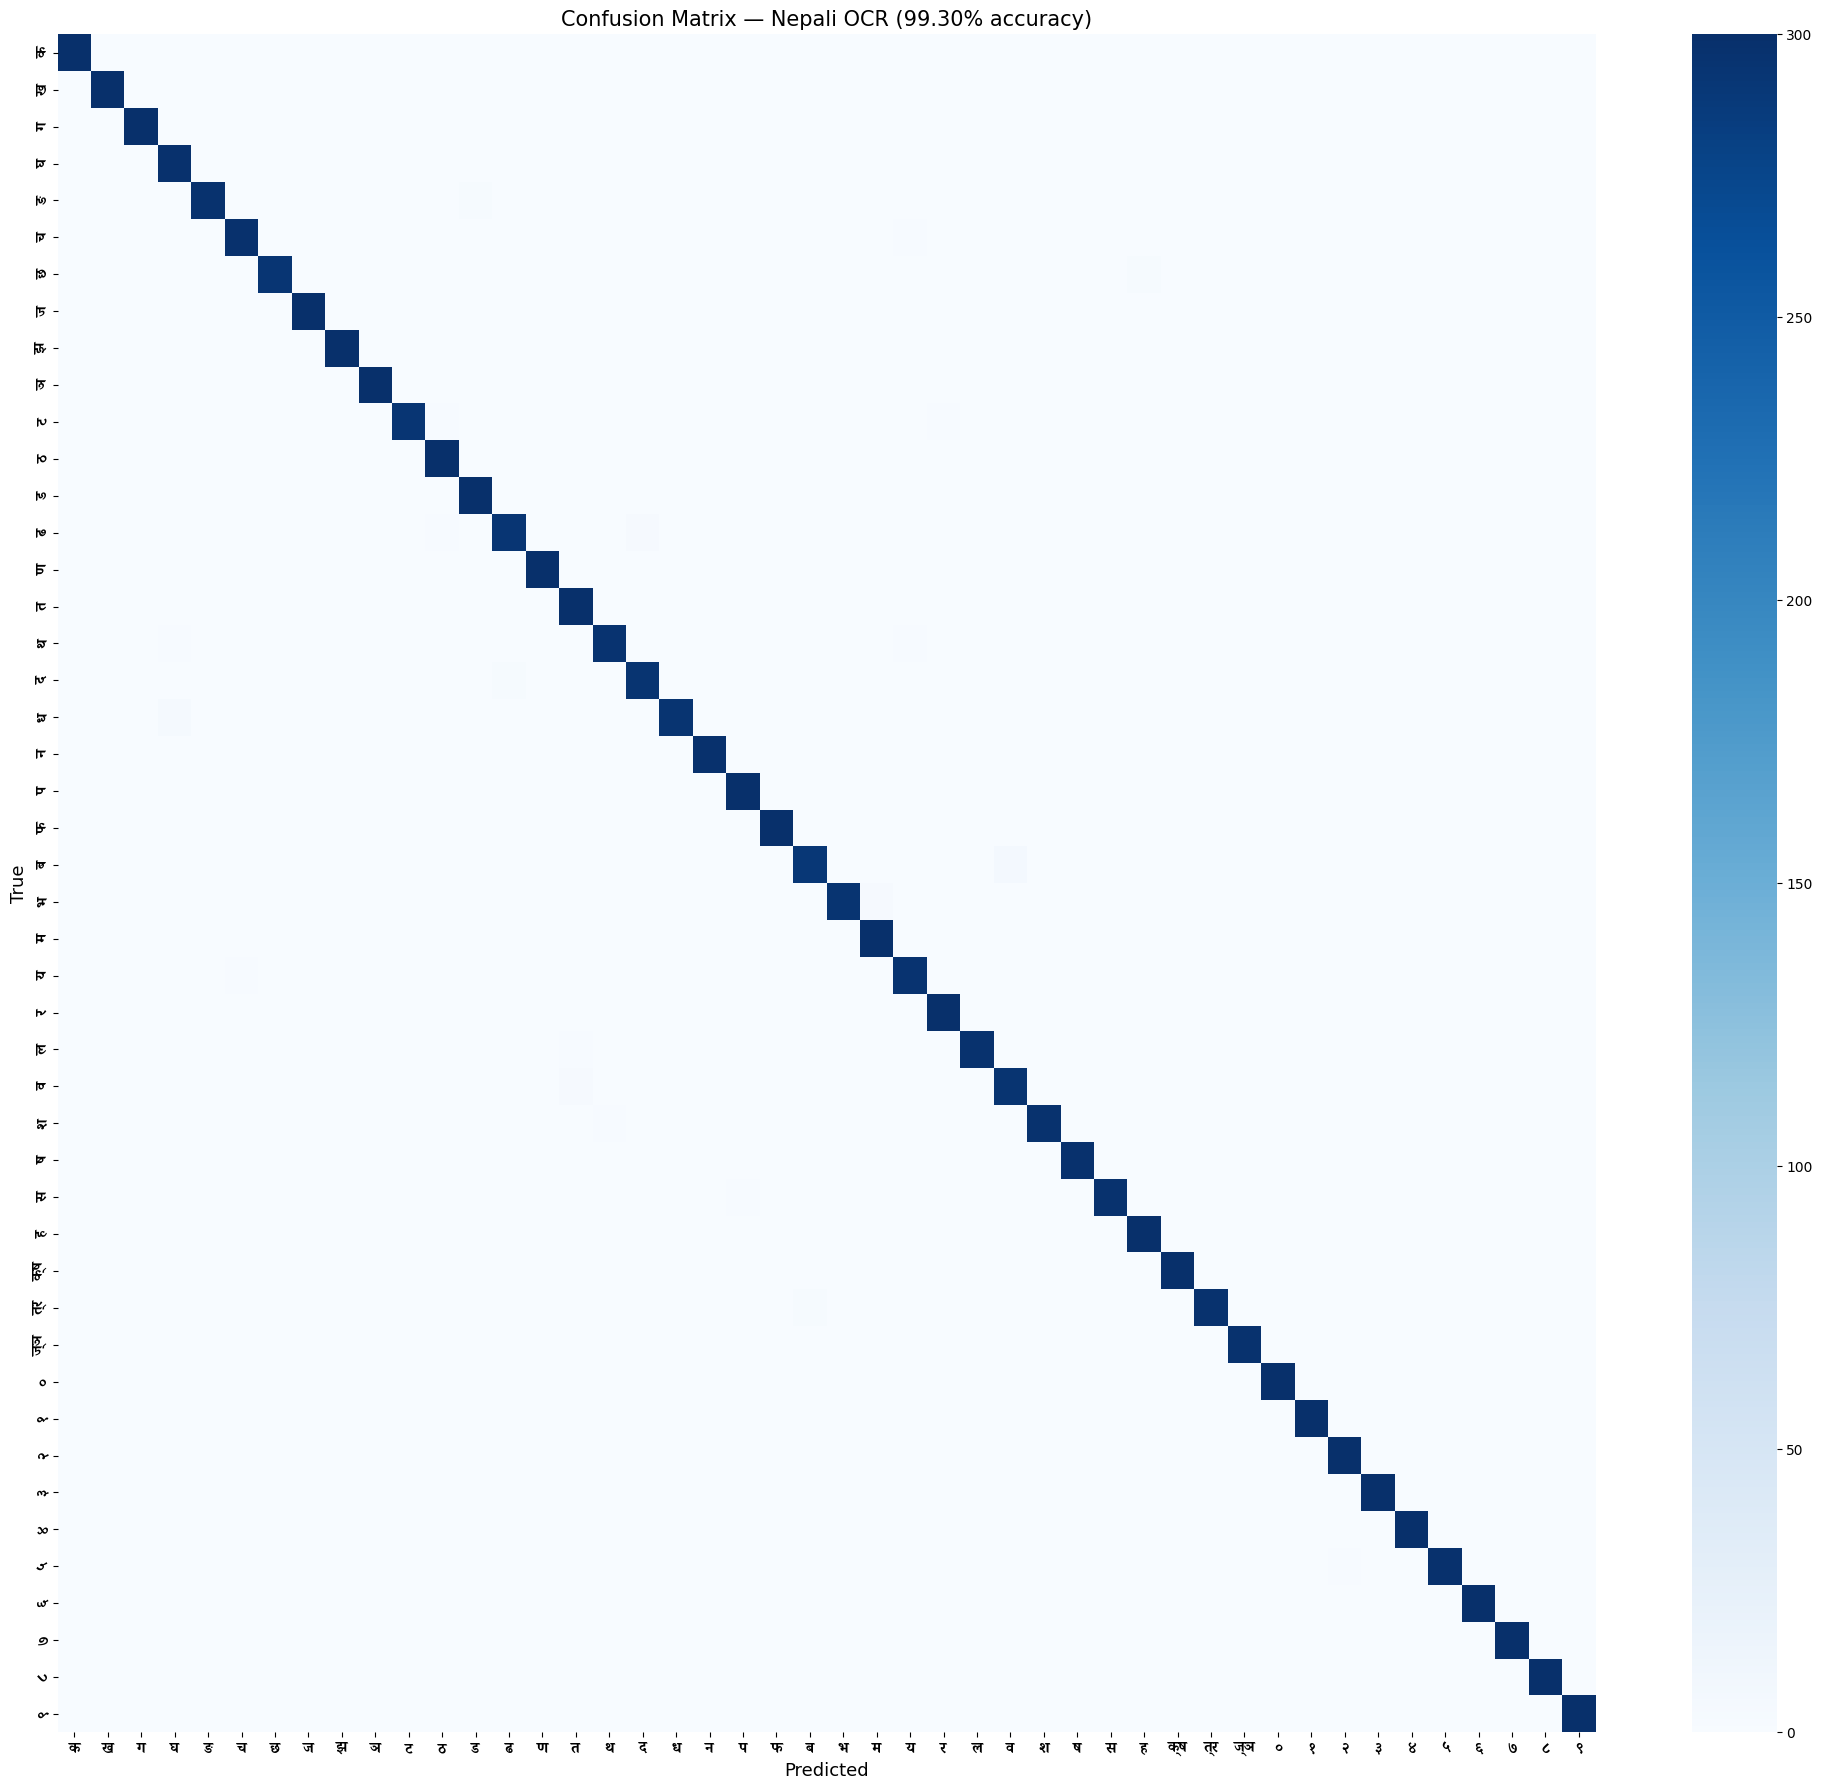


Per-class accuracy:
  क → 299/300 = 99.7%
  ख → 300/300 = 100.0%
  ग → 299/300 = 99.7%
  घ → 298/300 = 99.3%
  ङ → 297/300 = 99.0%
  च → 298/300 = 99.3%
  छ → 293/300 = 97.7%
  ज → 299/300 = 99.7%
  झ → 300/300 = 100.0%
  ञ → 299/300 = 99.7%
  ट → 294/300 = 98.0%
  ठ → 300/300 = 100.0%
  ड → 300/300 = 100.0%
  ढ → 294/300 = 98.0%
  ण → 300/300 = 100.0%
  त → 299/300 = 99.7%
  थ → 296/300 = 98.7%
  द → 295/300 = 98.3%
  ध → 295/300 = 98.3%
  न → 298/300 = 99.3%
  प → 299/300 = 99.7%
  फ → 300/300 = 100.0%
  ब → 291/300 = 97.0%
  भ → 295/300 = 98.3%
  म → 300/300 = 100.0%
  य → 296/300 = 98.7%
  र → 299/300 = 99.7%
  ल → 297/300 = 99.0%
  व → 295/300 = 98.3%
  श → 297/300 = 99.0%
  ष → 298/300 = 99.3%
  स → 297/300 = 99.0%
  ह → 300/300 = 100.0%
  क्ष → 299/300 = 99.7%
  त्र → 297/300 = 99.0%
  ज्ञ → 297/300 = 99.0%
  ० → 300/300 = 100.0%
  १ → 299/300 = 99.7%
  २ → 299/300 = 99.7%
  ३ → 299/300 = 99.7%
  ४ → 300/300 = 100.0%
  ५ → 298/300 = 99.3%
  ६ → 299/300 = 99.7%
  ७ → 300/300 = 1

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ── Load saved model ──────────────────────────────────────
class NepaliOCR_CNN(nn.Module):
    def __init__(self, num_classes=46):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

CLASS_NAMES = ['क','ख','ग','घ','ङ','च','छ','ज','झ','ञ',
               'ट','ठ','ड','ढ','ण','त','थ','द','ध','न',
               'प','फ','ब','भ','म','य','र','ल','व','श',
               'ष','स','ह','क्ष','त्र','ज्ञ',
               '०','१','२','३','४','५','६','७','८','९']

device = torch.device('cpu')
model  = NepaliOCR_CNN(num_classes=46)
model.load_state_dict(torch.load('/home/kulraj/nepali_ocr/models/nepali_ocr_cnn.pth',
                                  map_location=device))
model.eval()
print("Model loaded!")

# ── Get all predictions ───────────────────────────────────
data   = np.load('/home/kulraj/nepali_ocr/data/dataset.npz')
X_test = data['arr_2']
y_test = data['arr_3'] - 1

all_preds = []
all_true  = []

with torch.no_grad():
    for i in range(len(X_test)):
        img    = torch.tensor(X_test[i].astype(np.float32) / 255.0)
        img    = (img.unsqueeze(0).unsqueeze(0) - 0.5) / 0.5
        out    = model(img)
        pred   = out.argmax(1).item()
        all_preds.append(pred)
        all_true.append(y_test[i])

print(f"Total predictions: {len(all_preds)}")

# ── Plot confusion matrix ─────────────────────────────────
cm   = confusion_matrix(all_true, all_preds)
prop = fm.FontProperties(
    fname='/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf')

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)

ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('True', fontsize=13)
ax.set_title('Confusion Matrix — Nepali OCR (99.30% accuracy)', fontsize=15)

# Apply Devanagari font to tick labels
for label in ax.get_xticklabels():
    label.set_fontproperties(prop)
    label.set_fontsize(11)
for label in ax.get_yticklabels():
    label.set_fontproperties(prop)
    label.set_fontsize(11)

plt.tight_layout()
plt.show()

# ── Print hardest classes ─────────────────────────────────
print("\nPer-class accuracy:")
for i in range(46):
    class_total   = (np.array(all_true) == i).sum()
    class_correct = cm[i, i]
    print(f"  {CLASS_NAMES[i]} → {class_correct}/{class_total} = {class_correct/class_total*100:.1f}%")